# Análise de Insights — Carteira de Criptomoedas

Este notebook é a segunda etapa analítica do projeto e tem dois objetivos principais:

1. **Extrair insights de negócio** a partir das simulações de carteiras e do histórico de preços das criptomoedas
2. **Preparar o terreno para Machine Learning**, identificando as variáveis e problemas que serão tratados pelos modelos

Os dados utilizados aqui foram gerados pelo notebook de EDA inicial (`EDA_Carteira.ipynb`) e estão disponíveis nos arquivos:

| Arquivo | Conteúdo |
|---------|----------|
| `historico_moedas.csv` | Retorno percentual diário e preço de cada moeda |
| `carteiras_simuladas.csv` | 10.000 carteiras com retorno, risco e índice de Sharpe |
| `composicao_carteiras.csv` | Composição (peso por moeda) de cada carteira simulada |

> **Contexto do projeto:** Trabalho Final — Desenvolvimento para Ciência de Dados II (CEUB)
> Entrega: 24/06/2026

## Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

## Carregamento dos Dados

Os três DataFrames exportados pelo notebook anterior são carregados aqui. O campo `date` é convertido para `datetime` e o `portfolio_id` é ajustado como índice categórico.

In [7]:
df_historico   = pd.read_csv(r'../data/historico_moedas.csv',     parse_dates=['date'])
df_carteiras   = pd.read_csv(r'../data/carteiras_simuladas.csv',  parse_dates=['data_execucao'])
df_composicao  = pd.read_csv(r'../data/composicao_carteiras.csv')

print('df_historico  :', df_historico.shape)
print('df_carteiras  :', df_carteiras.shape)
print('df_composicao :', df_composicao.shape)

df_historico  : (8760, 4)
df_carteiras  : (10000, 9)
df_composicao : (40000, 3)


In [8]:
df_historico.head()

,date,moeda,retorno,preco
0,2020-01-02,BTC-USD,-0.029819,6985.470215
1,2020-01-03,BTC-USD,0.051452,7344.884277
2,2020-01-04,BTC-USD,0.008955,7410.656738
3,2020-01-05,BTC-USD,0.000089,7411.317383
4,2020-01-06,BTC-USD,0.048291,7769.219238


In [9]:
df_carteiras.head()

,portfolio_id,Retornos,Riscos,Sharpes,BTC-USD comp,ETH-USD comp,XRP-USD comp,DASH-USD comp,data_execucao
0,0,0.002074,0.041010,0.050569,0.095683,0.388116,0.210814,0.305387,2026-04-30 14:48:59.508970
1,1,0.001921,0.042665,0.045020,0.130358,0.223313,0.183139,0.463189,2026-04-30 14:48:59.508970
2,2,0.002014,0.040911,0.049234,0.168473,0.224910,0.278017,0.328600,2026-04-30 14:48:59.508970
3,3,0.001912,0.039836,0.048001,0.329080,0.025527,0.320631,0.324763,2026-04-30 14:48:59.508970
4,4,0.001920,0.038238,0.050215,0.308005,0.268157,0.124118,0.299720,2026-04-30 14:48:59.508970


In [10]:
df_composicao.head()

,portfolio_id,moeda,peso
0,0,BTC-USD,0.095683
1,1,BTC-USD,0.130358
2,2,BTC-USD,0.168473
3,3,BTC-USD,0.329080
4,4,BTC-USD,0.308005


## Análise das Carteiras Simuladas

Com 10.000 carteiras geradas aleatoriamente, é possível explorar a distribuição de retornos, riscos e índices de Sharpe, além de identificar as carteiras com melhor e pior desempenho.

### Estatísticas Descritivas

In [11]:
df_carteiras[['Retornos', 'Riscos', 'Sharpes']].describe()

,Retornos,Riscos,Sharpes
count,10000.000000,10000.000000,10000.000000
mean,0.002015,0.039815,0.050778
std,0.000133,0.002710,0.004069
min,0.001611,0.032137,0.029898
25%,0.001929,0.037964,0.048280
50%,0.002015,0.039543,0.051171
75%,0.002100,0.041518,0.053876
max,0.002445,0.053870,0.058049


### Distribuição de Retorno, Risco e Índice de Sharpe

Os histogramas abaixo mostram como as 10.000 carteiras simuladas se distribuem em relação às três principais métricas.

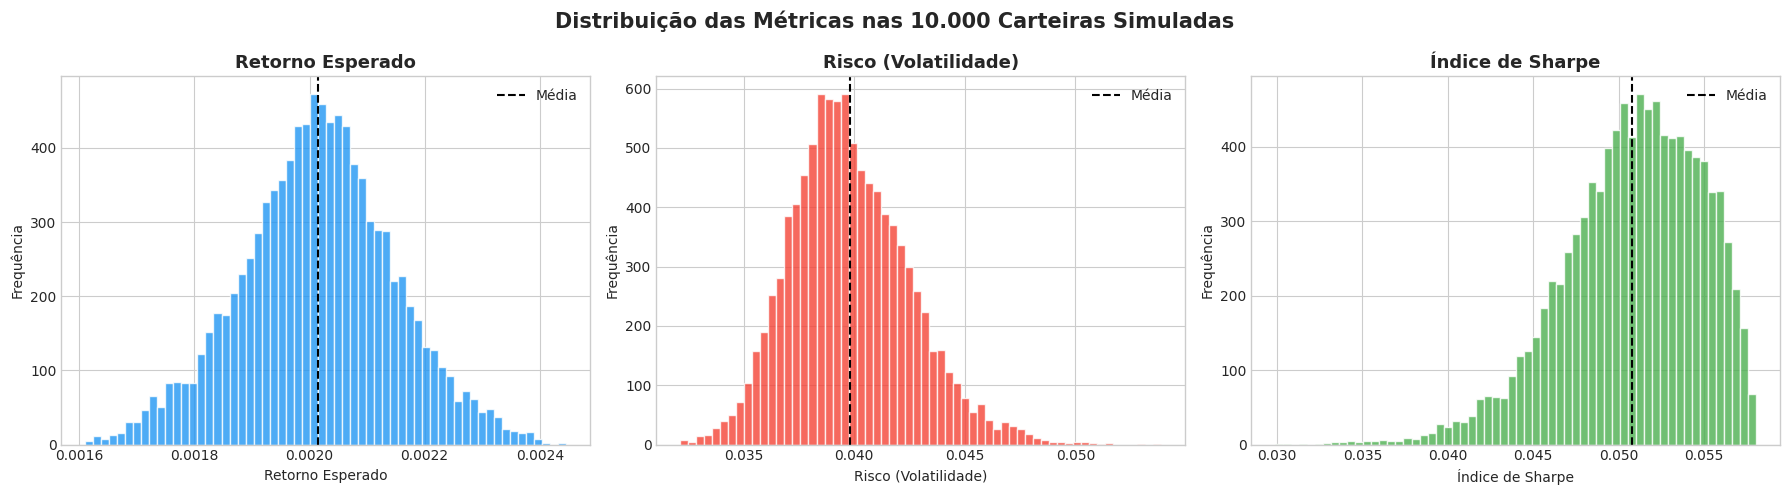

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metricas = [
    ('Retornos', 'Retorno Esperado',   '#2196F3'),
    ('Riscos',   'Risco (Volatilidade)', '#F44336'),
    ('Sharpes',  'Índice de Sharpe',    '#4CAF50'),
]

for ax, (col, label, cor) in zip(axes, metricas):
    ax.hist(df_carteiras[col], bins=60, color=cor, alpha=0.8, edgecolor='white')
    ax.axvline(df_carteiras[col].mean(), color='black', linestyle='--', linewidth=1.5, label='Média')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequência')
    ax.legend()

plt.suptitle('Distribuição das Métricas nas 10.000 Carteiras Simuladas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Fronteira Eficiente

O gráfico abaixo representa a **Fronteira Eficiente de Markowitz**: cada ponto é uma carteira simulada, colorida pelo seu índice de Sharpe. Carteiras à esquerda têm menor risco; carteiras acima têm maior retorno. A região ótima concentra os pontos mais azuis (Sharpe mais alto).

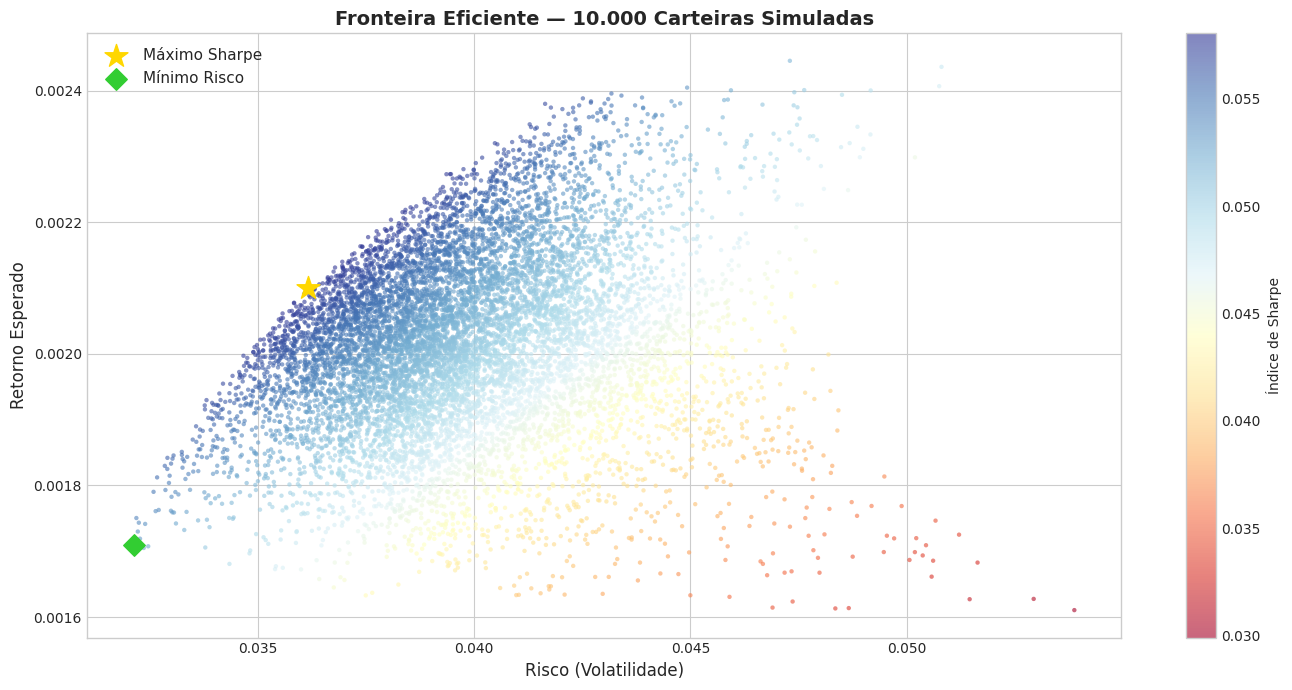

In [13]:
fig, ax = plt.subplots(figsize=(14, 7))

scatter = ax.scatter(
    df_carteiras['Riscos'],
    df_carteiras['Retornos'],
    c=df_carteiras['Sharpes'],
    cmap='RdYlBu',
    alpha=0.6,
    s=10,
    edgecolors='none'
)

# Marcar carteira de máximo Sharpe
idx_max_sharpe = df_carteiras['Sharpes'].idxmax()
ax.scatter(
    df_carteiras.loc[idx_max_sharpe, 'Riscos'],
    df_carteiras.loc[idx_max_sharpe, 'Retornos'],
    marker='*', color='gold', s=300, zorder=5, label='Máximo Sharpe'
)

# Marcar carteira de mínimo risco
idx_min_risco = df_carteiras['Riscos'].idxmin()
ax.scatter(
    df_carteiras.loc[idx_min_risco, 'Riscos'],
    df_carteiras.loc[idx_min_risco, 'Retornos'],
    marker='D', color='limegreen', s=120, zorder=5, label='Mínimo Risco'
)

plt.colorbar(scatter, ax=ax, label='Índice de Sharpe')
ax.set_xlabel('Risco (Volatilidade)', fontsize=12)
ax.set_ylabel('Retorno Esperado', fontsize=12)
ax.set_title('Fronteira Eficiente — 10.000 Carteiras Simuladas', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Carteiras de Destaque

Extraindo as carteiras com melhor e pior Sharpe para entender que composição de ativos maximiza (ou minimiza) a relação retorno/risco.

In [14]:
colunas_comp = [c for c in df_carteiras.columns if 'comp' in c]

top5_sharpe  = df_carteiras.nlargest(5,  'Sharpes')[['portfolio_id', 'Retornos', 'Riscos', 'Sharpes'] + colunas_comp]
bot5_sharpe  = df_carteiras.nsmallest(5, 'Sharpes')[['portfolio_id', 'Retornos', 'Riscos', 'Sharpes'] + colunas_comp]

print('Top 5 — Maior Índice de Sharpe')
display(top5_sharpe.reset_index(drop=True))

print('\nBottom 5 — Menor Índice de Sharpe')
display(bot5_sharpe.reset_index(drop=True))

Top 5 — Maior Índice de Sharpe


,portfolio_id,Retornos,Riscos,Sharpes,BTC-USD comp,ETH-USD comp,XRP-USD comp,DASH-USD comp
0,3086,0.002099,0.036168,0.058049,0.404756,0.404331,0.189785,0.001128
1,3893,0.002178,0.037551,0.057987,0.288243,0.514481,0.192622,0.004653
2,5004,0.002078,0.035840,0.057975,0.428932,0.422155,0.148522,0.000391
3,7764,0.002091,0.036072,0.057969,0.408656,0.449936,0.141261,0.000147
4,8115,0.002077,0.035839,0.057956,0.433928,0.371559,0.190428,0.004085



Bottom 5 — Menor Índice de Sharpe


,portfolio_id,Retornos,Riscos,Sharpes,BTC-USD comp,ETH-USD comp,XRP-USD comp,DASH-USD comp
0,8245,0.001611,0.053870,0.029898,0.029885,0.020105,0.034530,0.915481
1,2332,0.001628,0.052930,0.030750,0.042609,0.023656,0.048384,0.885351
2,707,0.001627,0.051451,0.031626,0.087160,0.024509,0.042152,0.846178
3,6798,0.001683,0.051634,0.032592,0.022874,0.094691,0.049273,0.833162
4,1999,0.001661,0.050573,0.032853,0.077955,0.065231,0.045262,0.811552


### Composição Média por Quartil de Sharpe

Dividindo as carteiras em 4 quartis pelo Sharpe, é possível observar que existe uma tendência de composição que favorece o desempenho ajustado ao risco.

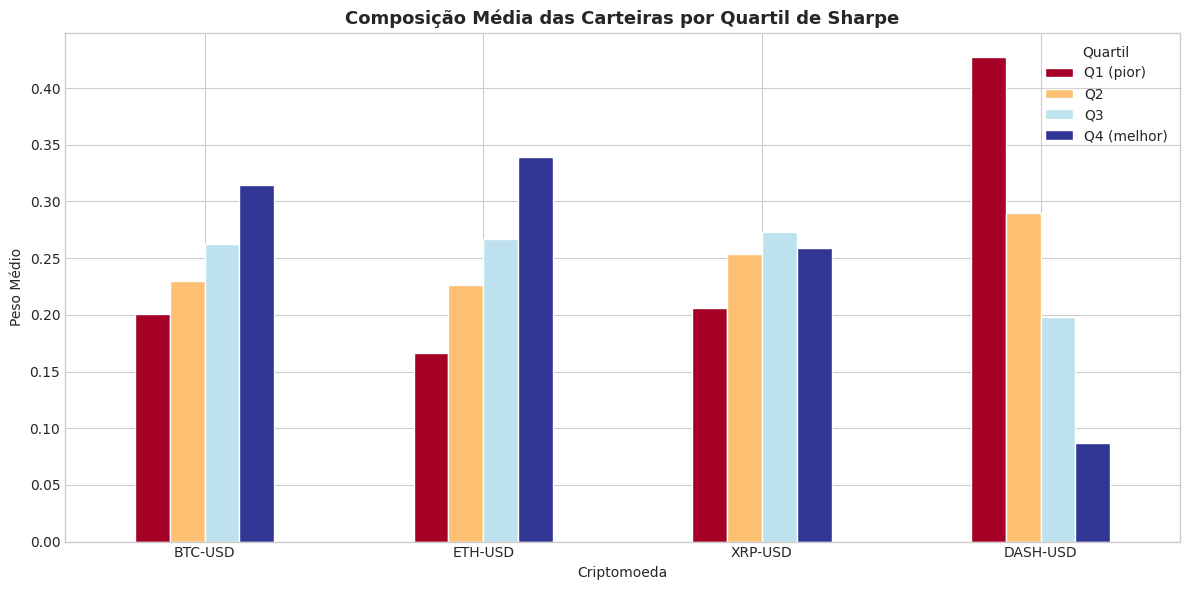

In [15]:
df_carteiras['quartil_sharpe'] = pd.qcut(df_carteiras['Sharpes'], q=4, labels=['Q1 (pior)', 'Q2', 'Q3', 'Q4 (melhor)'])

composicao_quartil = df_carteiras.groupby('quartil_sharpe')[colunas_comp].mean()
composicao_quartil.columns = [c.replace(' comp', '') for c in composicao_quartil.columns]

composicao_quartil.T.plot.bar(figsize=(12, 6), colormap='RdYlBu', edgecolor='white')
plt.title('Composição Média das Carteiras por Quartil de Sharpe', fontsize=13, fontweight='bold')
plt.xlabel('Criptomoeda')
plt.ylabel('Peso Médio')
plt.xticks(rotation=0)
plt.legend(title='Quartil')
plt.tight_layout()
plt.show()

## Análise Histórica das Criptomoedas

A série histórica de preços e retornos diários permite entender o comportamento individual de cada ativo, bem como as relações entre eles.

### Evolução Temporal dos Preços

Evolução do preço de fechamento de cada criptomoeda no período analisado (2020–2025).

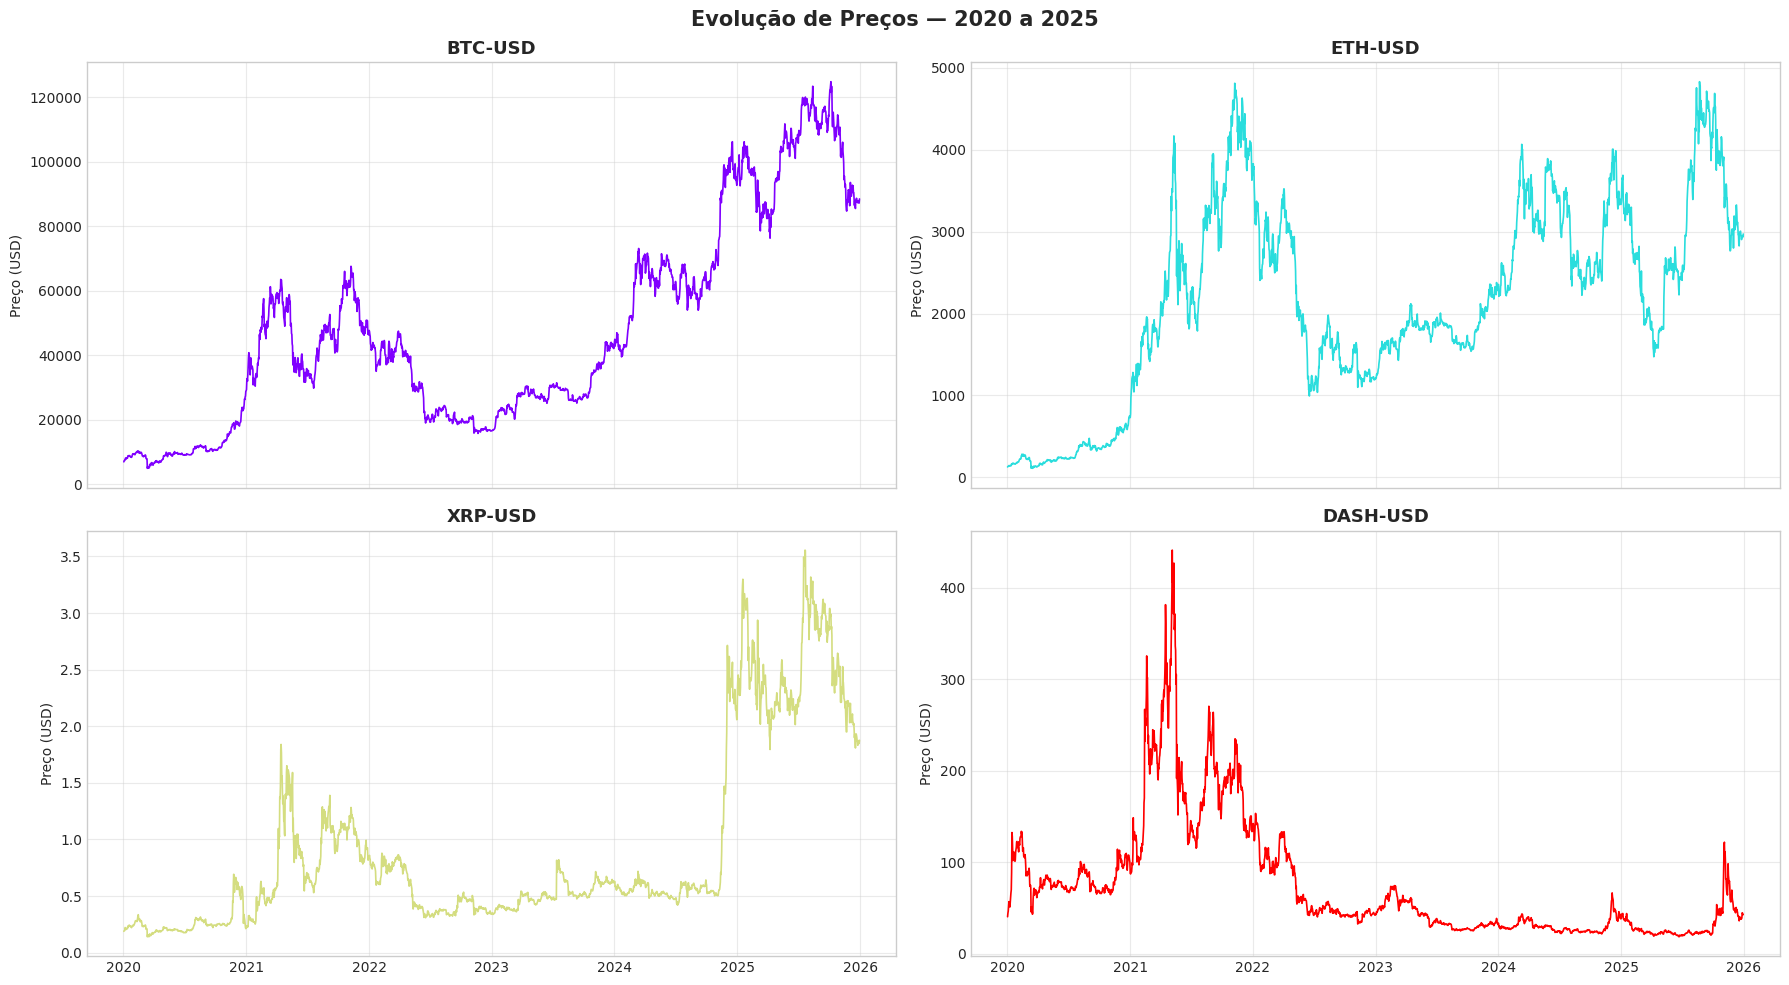

In [16]:
moedas = df_historico['moeda'].unique()
cores  = cm.rainbow(np.linspace(0, 1, len(moedas)))

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True)

for ax, moeda, cor in zip(axes.flat, moedas, cores):
    dados = df_historico[df_historico['moeda'] == moeda].sort_values('date')
    ax.plot(dados['date'], dados['preco'], color=cor, linewidth=1.2)
    ax.set_title(moeda, fontsize=13, fontweight='bold')
    ax.set_ylabel('Preço (USD)')
    ax.grid(True, alpha=0.4)

plt.suptitle('Evolução de Preços — 2020 a 2025', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Retorno Acumulado Normalizado

Comparação do desempenho relativo de cada ativo a partir de uma base 1 (início de 2020). Valores acima de 1 indicam valorização; abaixo de 1, desvalorização em relação ao início do período.

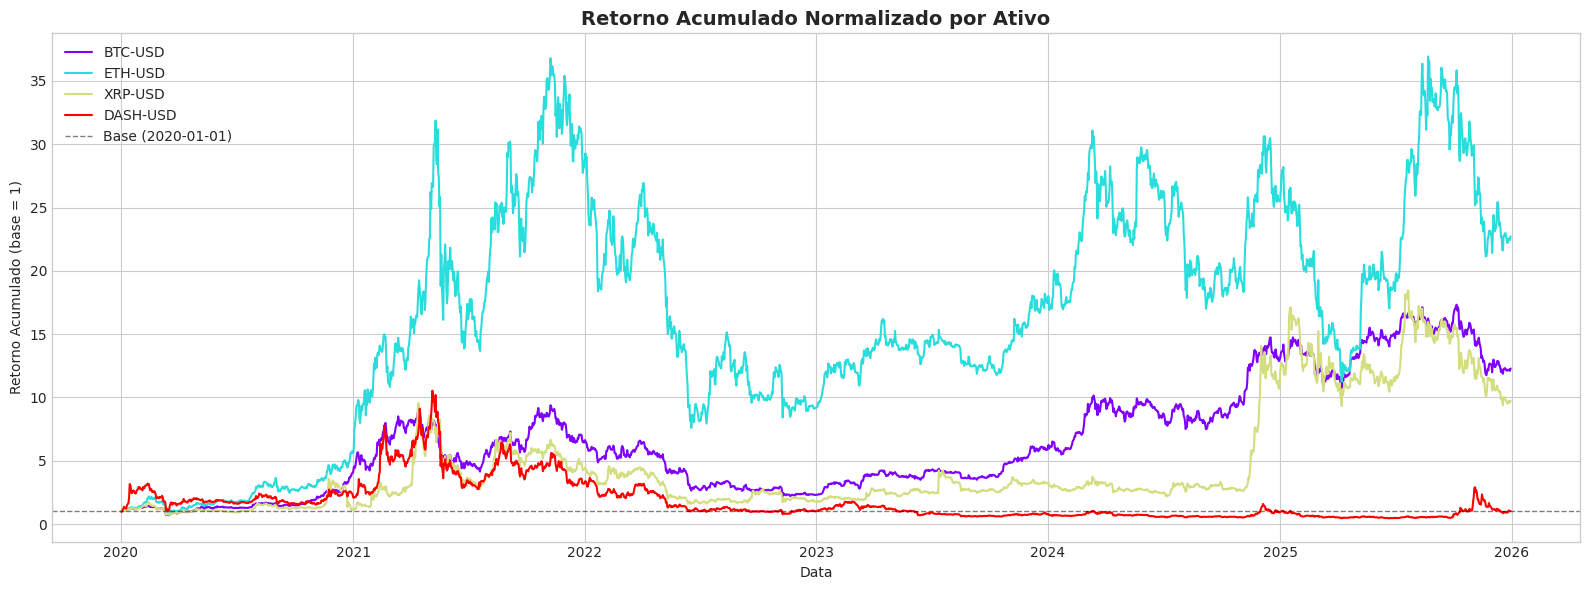

In [17]:
fig, ax = plt.subplots(figsize=(16, 6))

for moeda, cor in zip(moedas, cores):
    dados = df_historico[df_historico['moeda'] == moeda].sort_values('date')
    retorno_acum = (1 + dados['retorno']).cumprod()
    ax.plot(dados['date'], retorno_acum, label=moeda, color=cor, linewidth=1.5)

ax.axhline(1, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Base (2020-01-01)')
ax.set_title('Retorno Acumulado Normalizado por Ativo', fontsize=14, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Retorno Acumulado (base = 1)')
ax.legend()
plt.tight_layout()
plt.show()

### Distribuição dos Retornos Diários

A distribuição do retorno percentual diário revela o perfil de risco de cada ativo. Caudas mais largas indicam maior probabilidade de movimentos extremos.

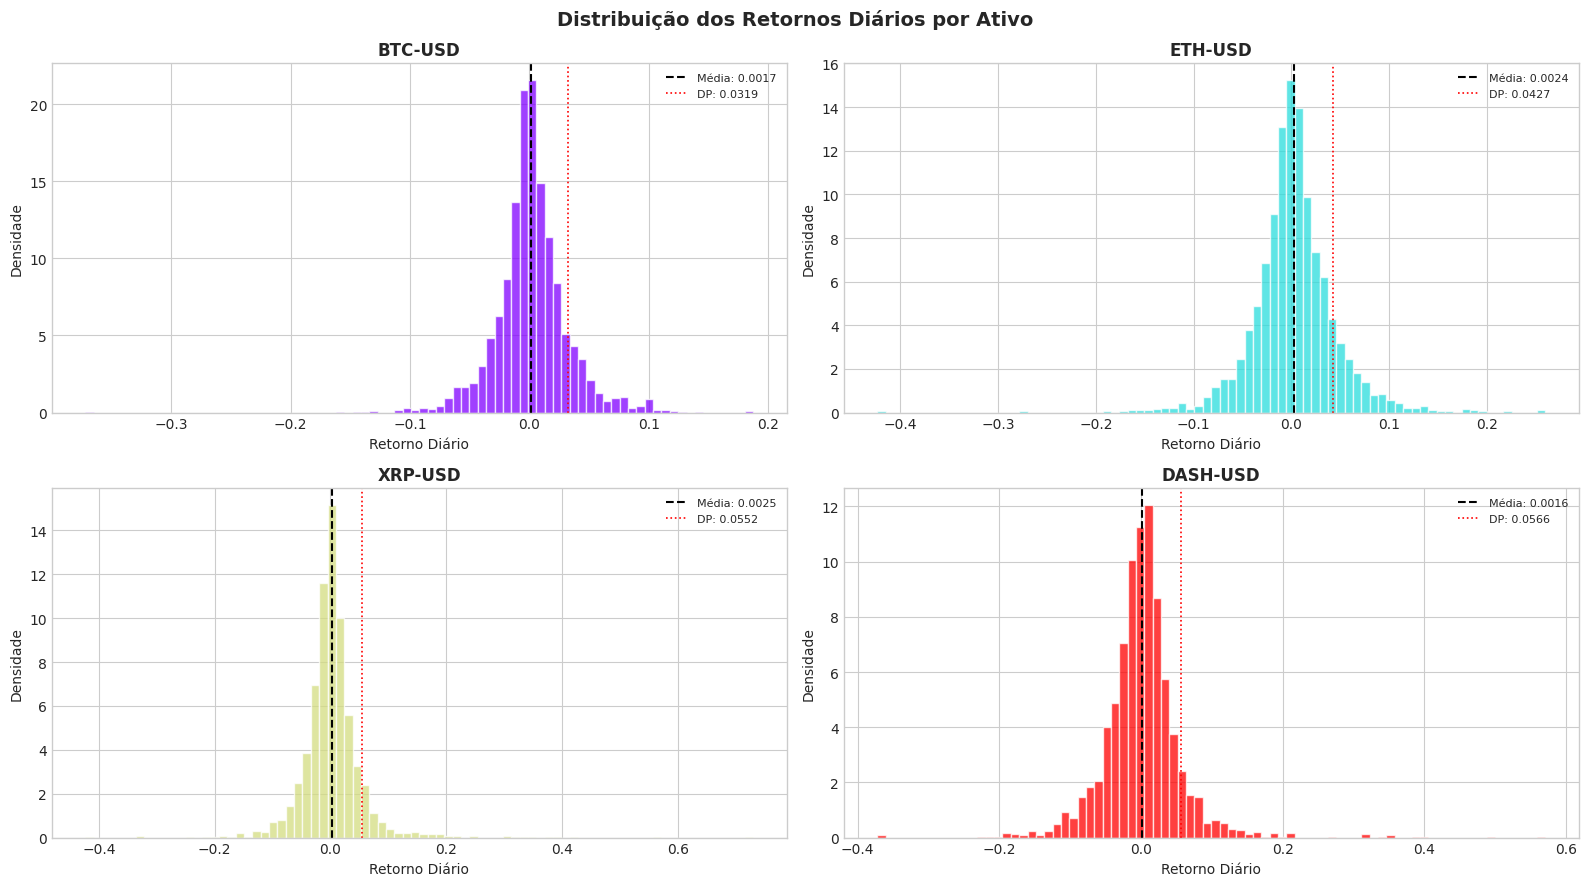

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

for ax, moeda, cor in zip(axes.flat, moedas, cores):
    dados = df_historico[df_historico['moeda'] == moeda]['retorno'].dropna()
    ax.hist(dados, bins=80, color=cor, alpha=0.75, edgecolor='white', density=True)
    ax.axvline(dados.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Média: {dados.mean():.4f}')
    ax.axvline(dados.std(),  color='red',   linestyle=':',  linewidth=1.2, label=f'DP: {dados.std():.4f}')
    ax.set_title(moeda, fontsize=12, fontweight='bold')
    ax.set_xlabel('Retorno Diário')
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=8)

plt.suptitle('Distribuição dos Retornos Diários por Ativo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Matriz de Correlação entre Ativos

A correlação entre os retornos diários dos ativos é fundamental para a diversificação. Quanto menor a correlação entre dois ativos, maior o benefício de tê-los juntos na carteira.

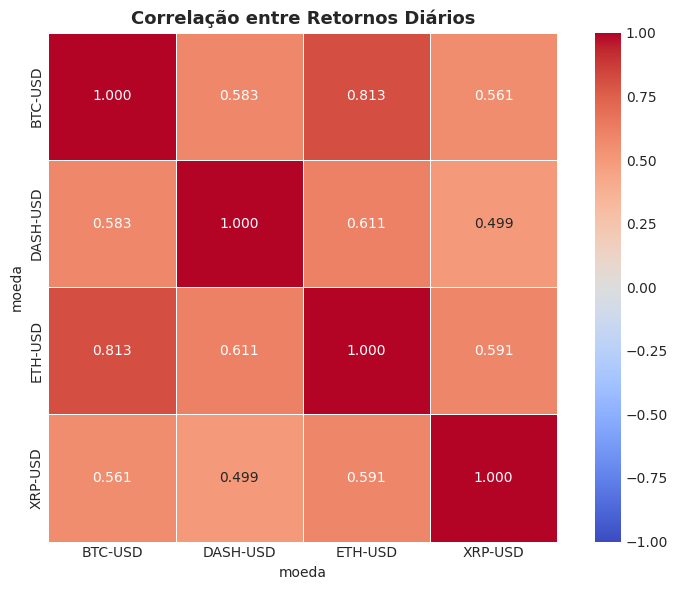

In [19]:
pivot_retornos = df_historico.pivot_table(index='date', columns='moeda', values='retorno')
matriz_corr    = pivot_retornos.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool), k=1)
sns.heatmap(
    matriz_corr,
    annot=True, fmt='.3f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax
)
ax.set_title('Correlação entre Retornos Diários', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Volatilidade Móvel (Rolling 30 dias)

A volatilidade calculada em janelas de 30 dias mostra como o risco de cada ativo varia ao longo do tempo, revelando períodos de maior instabilidade no mercado.

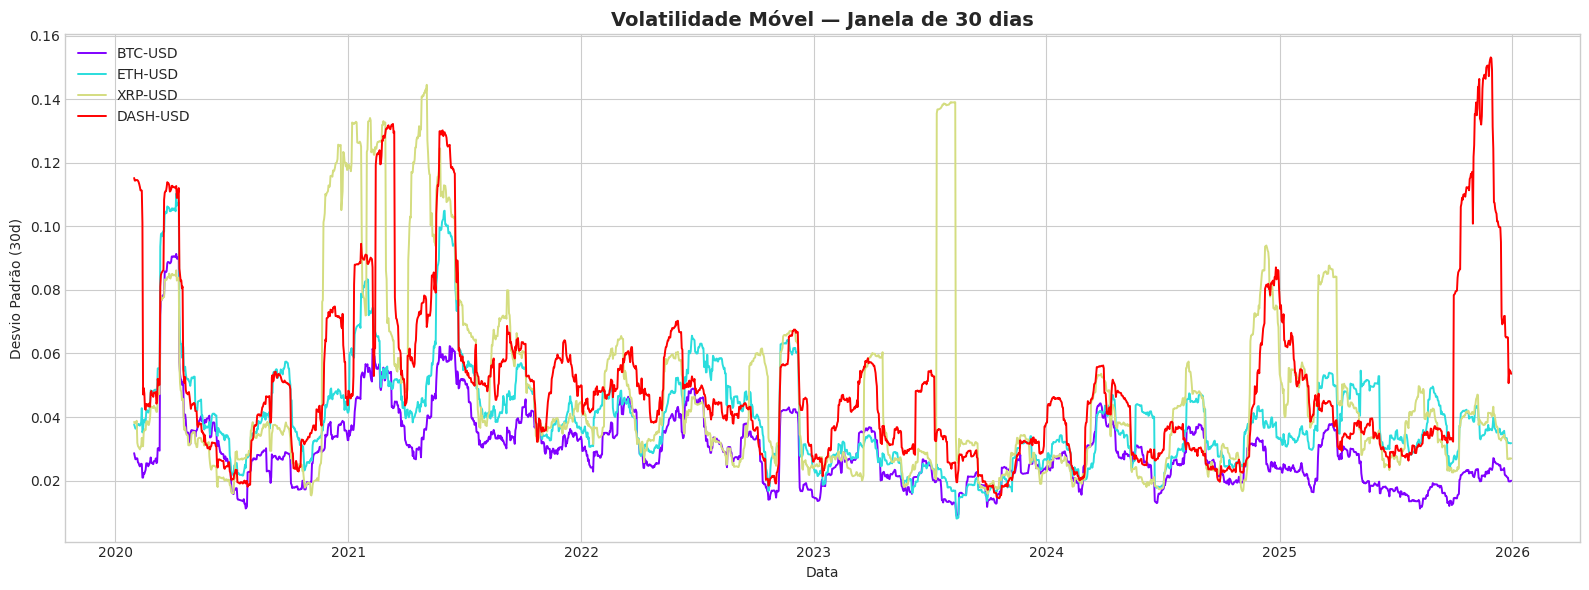

In [20]:
fig, ax = plt.subplots(figsize=(16, 6))

for moeda, cor in zip(moedas, cores):
    dados = df_historico[df_historico['moeda'] == moeda].sort_values('date')
    vol_movel = dados['retorno'].rolling(30).std()
    ax.plot(dados['date'], vol_movel, label=moeda, color=cor, linewidth=1.4)

ax.set_title('Volatilidade Móvel — Janela de 30 dias', fontsize=14, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Desvio Padrão (30d)')
ax.legend()
plt.tight_layout()
plt.show()

## Insights de Negócio

A seguir são apresentados os principais insights extraídos das análises anteriores, com foco em decisões práticas de alocação e gestão de risco.

### Insight 1 — A diversificação reduz o risco, mas não uniformemente

A matriz de correlação revela que nem todos os ativos se comportam de forma independente. Pares com alta correlação (ex.: BTC e ETH tendem a se mover juntos) oferecem menor benefício de diversificação do que pares com correlação mais baixa. Uma carteira bem construída deve priorizar ativos com baixa correlação entre si.

In [21]:
# Correlações par a par (excluindo diagonal)
corr_flat = matriz_corr.where(~np.eye(len(matriz_corr), dtype=bool)).stack().sort_values()
print('Pares com menor correlação (maior benefício de diversificação):')
print(corr_flat.head(4).to_string())
print('\nPares com maior correlação (menor benefício de diversificação):')
print(corr_flat.tail(4).to_string())

Pares com menor correlação (maior benefício de diversificação):
moeda     moeda   
DASH-USD  XRP-USD     0.498531
XRP-USD   DASH-USD    0.498531
          BTC-USD     0.561151
BTC-USD   XRP-USD     0.561151

Pares com maior correlação (menor benefício de diversificação):
moeda     moeda   
BTC-USD   BTC-USD    NaN
DASH-USD  DASH-USD   NaN
ETH-USD   ETH-USD    NaN
XRP-USD   XRP-USD    NaN


### Insight 2 — A carteira de máximo Sharpe não é a de maior retorno

O Índice de Sharpe penaliza o risco: carteiras com retorno muito alto frequentemente carregam volatilidade desproporcional. A carteira ótima segundo Markowitz equilibra as duas dimensões, e raramente coincide com a de maior retorno bruto.

In [22]:
carteira_max_sharpe  = df_carteiras.loc[df_carteiras['Sharpes'].idxmax()]
carteira_max_retorno = df_carteiras.loc[df_carteiras['Retornos'].idxmax()]

comparativo = pd.DataFrame({
    'Máximo Sharpe':  carteira_max_sharpe[['Retornos', 'Riscos', 'Sharpes']],
    'Máximo Retorno': carteira_max_retorno[['Retornos', 'Riscos', 'Sharpes']]
})
print(comparativo)

         Máximo Sharpe Máximo Retorno
Retornos      0.002099       0.002445
Riscos        0.036168       0.047297
Sharpes       0.058049       0.051705


### Insight 3 — Existe uma faixa de composição que domina as carteiras do Q4

Carteiras no quartil superior de Sharpe tendem a ter uma distribuição de pesos diferente das do quartil inferior. Identificar essa faixa é o primeiro passo para uma estratégia de alocação baseada em dados.

In [23]:
print('Composição média — Q4 (melhor Sharpe):')
print(composicao_quartil.loc['Q4 (melhor)'].sort_values(ascending=False).to_string())
print('\nComposição média — Q1 (pior Sharpe):')
print(composicao_quartil.loc['Q1 (pior)'].sort_values(ascending=False).to_string())

Composição média — Q4 (melhor Sharpe):
ETH-USD     0.338866
BTC-USD     0.314674
XRP-USD     0.259326
DASH-USD    0.087134

Composição média — Q1 (pior Sharpe):
DASH-USD    0.427402
XRP-USD     0.206331
BTC-USD     0.200321
ETH-USD     0.165946


### Insight 4 — Períodos de alta volatilidade são sistêmicos

O gráfico de volatilidade móvel mostra que os picos de risco tendem a ocorrer simultaneamente em todos os ativos, sugerindo que choques externos (eventos macro, regulatório, crises de liquidez) afetam o mercado cripto como um todo. Isso reforça a importância de monitorar indicadores externos, não apenas o comportamento individual dos ativos.

In [24]:
# Identificar as datas de maior volatilidade simultânea
vol_media_diaria = pivot_retornos.std(axis=1).rolling(30).mean()
top_volatilidade = vol_media_diaria.nlargest(5)
print('Períodos de maior volatilidade sistêmica (média 30d):')
print(top_volatilidade.to_string())

Períodos de maior volatilidade sistêmica (média 30d):
date
2021-01-14    0.062279
2021-02-22    0.062181
2021-02-26    0.061688
2025-11-28    0.061682
2025-11-29    0.061678


### Insight 5 — BTC domina retorno; diversificação atenua risco de cauda

O Bitcoin historicamente apresenta os maiores retornos acumulados do conjunto, mas também as caudas mais largas na distribuição de retornos diários. Manter BTC como ativo âncora com alocação controlada, complementado por ativos de menor volatilidade, é uma estratégia que o modelo de Markowitz consistentemente favorece.

In [25]:
stats_por_moeda = df_historico.groupby('moeda')['retorno'].agg(
    retorno_medio='mean',
    volatilidade='std',
    curtose='kurt',
    assimetria='skew'
).round(6)

stats_por_moeda['sharpe_individual'] = (stats_por_moeda['retorno_medio'] / stats_por_moeda['volatilidade']).round(4)
print(stats_por_moeda.to_string())

          retorno_medio  volatilidade    curtose  assimetria  sharpe_individual
moeda                                                                          
BTC-USD        0.001664      0.031917  11.568513   -0.480910             0.0521
DASH-USD       0.001559      0.056557  14.730194    1.363839             0.0276
ETH-USD        0.002354      0.042747   8.349405   -0.196943             0.0551
XRP-USD        0.002489      0.055248  28.368455    2.291466             0.0451


## Próximos Passos — Machine Learning

As análises realizadas até aqui estabelecem a base para a aplicação de algoritmos de Machine Learning. O objetivo é duplo:

1. **Classificar** carteiras como boas ou ruins (acima/abaixo da mediana de Sharpe)
2. **Prever** o comportamento futuro dos preços das criptomoedas

---

### Problemas de ML mapeados

#### Classificação — *"Esta carteira é boa?"*

A variável-alvo será `sharpe_label` (binário): carteiras com Sharpe acima da mediana = 1, abaixo = 0. Os features serão os pesos de cada ativo na carteira.

Algoritmos a implementar:

| Algoritmo | Justificativa |
|-----------|---------------|
| KNN | Baseline por similaridade de composição |
| Árvore de Decisão | Regras interpretáveis de composição |
| Random Forest | Redução de variância, feature importance |
| Regressão Logística | Fronteira linear entre carteiras boas e ruins |

#### Regressão — *"Qual o retorno esperado desta carteira?"*

A variável-alvo será `Retornos` (contínuo), com os pesos dos ativos como features.

| Algoritmo | Justificativa |
|-----------|---------------|
| Regressão Linear | Relação linear entre composição e retorno |

#### Rede Neural — *"Como o preço desta cripto vai se comportar amanhã?"*

Para a previsão de séries temporais, será utilizada uma **RNN com células LSTM** (Long Short-Term Memory), arquitetura especialmente eficaz para capturar dependências de longo prazo em sequências financeiras.

A RNN/LSTM complementa os modelos clássicos por ser capaz de aprender padrões temporais que variáveis estáticas de composição não capturam — como tendências, sazonalidade e regimes de volatilidade.

### Preparação dos labels para ML

Gerando a variável-alvo binária `sharpe_label` que será usada nos modelos de classificação, e exportando o dataset enriquecido para uso no próximo notebook.

In [26]:
mediana_sharpe = df_carteiras['Sharpes'].median()

df_ml = df_carteiras.copy()
df_ml['sharpe_label'] = (df_ml['Sharpes'] >= mediana_sharpe).astype(int)

print(f'Mediana do Sharpe: {mediana_sharpe:.6f}')
print(f'Distribuição do label:')
print(df_ml['sharpe_label'].value_counts().to_string())

df_ml.head()

Mediana do Sharpe: 0.051171
Distribuição do label:
sharpe_label
0    5000
1    5000


,portfolio_id,Retornos,Riscos,Sharpes,BTC-USD comp,ETH-USD comp,XRP-USD comp,DASH-USD comp,data_execucao,quartil_sharpe,sharpe_label
0,0,0.002074,0.041010,0.050569,0.095683,0.388116,0.210814,0.305387,2026-04-30 14:48:59.508970,Q2,0
1,1,0.001921,0.042665,0.045020,0.130358,0.223313,0.183139,0.463189,2026-04-30 14:48:59.508970,Q1 (pior),0
2,2,0.002014,0.040911,0.049234,0.168473,0.224910,0.278017,0.328600,2026-04-30 14:48:59.508970,Q2,0
3,3,0.001912,0.039836,0.048001,0.329080,0.025527,0.320631,0.324763,2026-04-30 14:48:59.508970,Q1 (pior),0
4,4,0.001920,0.038238,0.050215,0.308005,0.268157,0.124118,0.299720,2026-04-30 14:48:59.508970,Q2,0


In [28]:
df_ml.to_csv('../data/carteiras_ml.csv', index=False)
print('Exportado: carteiras_ml.csv')

Exportado: carteiras_ml.csv
